# Assignment 1: Data Cleaning

In this assignment, we will learn why data is often inconsistent and how to clean it. Real-world data can have missing values, mixed types, or duplicate entries. Our goal is to handle these issues before we can perform any analysis.

## 1. Loading the Data

First, we will load the raw data from our `assignment1_data.json` file to see what it looks like.

In [1]:
import json

with open('assignment1_data.json', 'r') as f:
    data = json.load(f)

print(data)

[{'id': 1, 'customer_name': 'Alice', 'rating': 5, 'feedback': 'Excellent service and fast delivery.', 'product': 'Laptop', 'date': '2026-08-01'}, {'id': 2, 'customer_name': 'Bob', 'rating': 4, 'feedback': 'Product quality is good.', 'product': 'Mouse', 'date': '2026-08-02'}, {'id': 3, 'customer_name': 'Charlie', 'rating': 1, 'feedback': 'Poor quality.', 'product': 'Keyboard', 'date': '2026-08-03'}]


## 2. Handling Missing Data

Some users might not have provided their age. We need to handle this gracefully by setting missing age values to `None`.

In [2]:
def clean_missing_data(data):
    for user in data:
        raw_age = user.get('age')
        if raw_age == '' or raw_age is None:
            user['age'] = None
        print(user)

clean_missing_data(data)

{'id': 1, 'customer_name': 'Alice', 'rating': 5, 'feedback': 'Excellent service and fast delivery.', 'product': 'Laptop', 'date': '2026-08-01', 'age': None}
{'id': 2, 'customer_name': 'Bob', 'rating': 4, 'feedback': 'Product quality is good.', 'product': 'Mouse', 'date': '2026-08-02', 'age': None}
{'id': 3, 'customer_name': 'Charlie', 'rating': 1, 'feedback': 'Poor quality.', 'product': 'Keyboard', 'date': '2026-08-03', 'age': None}


## 3. Cleaning Specific Fields (e.g. Age)

Sometimes numerical data is written in text (like 'twenty'). We should convert these into standard integers for consistency.

In [3]:
def clean_age(data):
    text_to_num = {'one': 1, 'two': 2, 'three': 3, 'four': 4, 'five': 5, 'twenty': 20}
    for user in data:
        raw_age = str(user['age']).strip().lower()
        if raw_age in text_to_num:
            raw_age = text_to_num[raw_age]
        user['age'] = raw_age
        print(raw_age)

clean_age(data)

none
none
none


## 4. Handling Duplications

Finally, let's remove duplicate records based on the customer name.

In [4]:
def remove_duplicates(data):
    cleaned_data = []
    unique_users = set()
    
    for user in data:
        user_name = user.get('customer_name')
        if user_name in unique_users:
            continue
        
        unique_users.add(user_name)
        cleaned_data.append(user)
        
    return cleaned_data

cleaned_data = remove_duplicates(data)
for user in cleaned_data:
    print(user)

{'id': 1, 'customer_name': 'Alice', 'rating': 5, 'feedback': 'Excellent service and fast delivery.', 'product': 'Laptop', 'date': '2026-08-01', 'age': 'none'}
{'id': 2, 'customer_name': 'Bob', 'rating': 4, 'feedback': 'Product quality is good.', 'product': 'Mouse', 'date': '2026-08-02', 'age': 'none'}
{'id': 3, 'customer_name': 'Charlie', 'rating': 1, 'feedback': 'Poor quality.', 'product': 'Keyboard', 'date': '2026-08-03', 'age': 'none'}


## 5. Visualizing the Data

Let's visualize the ratings and products in our cleaned dataset to get a better understanding of what we have!

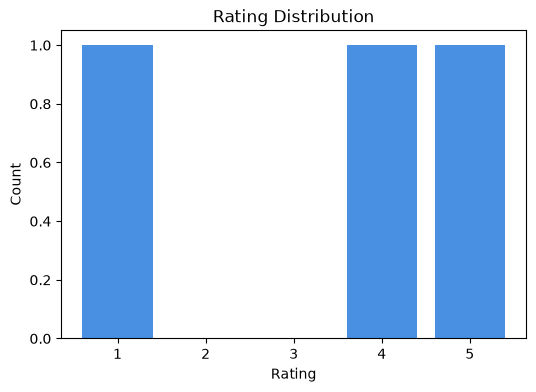

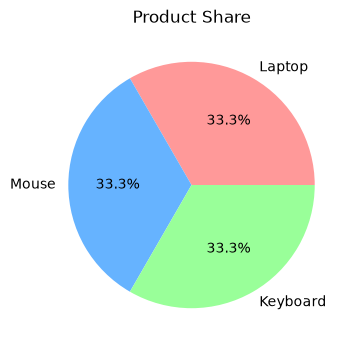

In [5]:
import matplotlib.pyplot as plt
from collections import Counter

# Extract ratings and products from the cleaned data
ratings = [user.get('rating') for user in cleaned_data if user.get('rating') is not None]
products = [user.get('product') for user in cleaned_data if user.get('product') is not None]

# 1. Plot Rating Distribution
plt.figure(figsize=(6, 4))
rating_counts = Counter(ratings)
plt.bar(rating_counts.keys(), rating_counts.values(), color='#4A90E2')
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks([1, 2, 3, 4, 5])
plt.show()

# 2. Plot Product Share
plt.figure(figsize=(6, 4))
product_counts = Counter(products)
plt.pie(product_counts.values(), labels=product_counts.keys(), autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99'])
plt.title('Product Share')
plt.show()
